In [5]:
# ============================================================
# NOVACRED – BIAS & FAIRNESS ANALYSIS
# MSc Business Analytics – Data Governance Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from datetime import datetime

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df = pd.read_json("data/cleaned_credit_applications.json")

print("\nDataset Loaded.")
print("Total records:", len(df))


# ------------------------------------------------------------
# 2. FLATTEN NESTED JSON
# ------------------------------------------------------------

df["gender"] = df["applicant_info"].apply(lambda x: x.get("gender") if isinstance(x, dict) else None)
df["dob"] = df["applicant_info"].apply(lambda x: x.get("date_of_birth") if isinstance(x, dict) else None)
df["zip_code"] = df["applicant_info"].apply(lambda x: x.get("zip_code") if isinstance(x, dict) else None)

df["approved"] = df["decision"].apply(lambda x: x.get("loan_approved") if isinstance(x, dict) else None)

df["annual_income"] = df["financials"].apply(lambda x: x.get("annual_income") if isinstance(x, dict) else None)
df["credit_history_months"] = df["financials"].apply(lambda x: x.get("credit_history_months") if isinstance(x, dict) else None)
df["debt_to_income"] = df["financials"].apply(lambda x: x.get("debt_to_income") if isinstance(x, dict) else None)

# Keep only relevant columns
df = df[["gender", "dob", "zip_code", "approved",
         "annual_income", "credit_history_months", "debt_to_income"]]

df.dropna(subset=["gender", "approved"], inplace=True)
df["approved"] = df["approved"].astype(int)


# ------------------------------------------------------------
# 3. GENDER DISPARATE IMPACT
# ------------------------------------------------------------

print("\n--- GENDER DISPARATE IMPACT ---")

approval_rates = df.groupby("gender")["approved"].mean()
print("\nApproval Rates by Gender:")
print(approval_rates)

# Formula
# ------------------------------------------------------------
# DI = P(Approval | Unprivileged) / P(Approval | Privileged)
# ------------------------------------------------------------


::contentReference[oaicite:0]{index=0}


if len(approval_rates) == 2:
    unpriv = approval_rates.min()
    priv = approval_rates.max()
    di = unpriv / priv
    print("\nDisparate Impact Ratio:", round(di, 3))

    if di < 0.8:
        print("⚠ Potential Gender Bias (DI < 0.8)")
    else:
        print("✓ No evidence of disparate impact under 80% rule")

# Bar chart
approval_rates.plot(kind="bar")
plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate")
plt.show()


# ------------------------------------------------------------
# 4. AGE-BASED DISCRIMINATION ANALYSIS
# ------------------------------------------------------------

print("\n--- AGE ANALYSIS ---")

def calculate_age(dob):
    try:
        birth = datetime.strptime(dob, "%Y-%m-%d")
        return (datetime.today() - birth).days // 365
    except:
        return np.nan

df["age"] = df["dob"].apply(calculate_age)
df.dropna(subset=["age"], inplace=True)

df["age_group"] = pd.cut(df["age"],
                         bins=[18, 30, 40, 50, 60, 100],
                         labels=["18-30", "30-40", "40-50", "50-60", "60+"])

age_rates = df.groupby("age_group")["approved"].mean()
print("\nApproval Rates by Age Group:")
print(age_rates)

age_rates.plot(kind="bar")
plt.title("Approval Rate by Age Group")
plt.ylabel("Approval Rate")
plt.show()


# ------------------------------------------------------------
# 5. PROXY DISCRIMINATION – ZIP CODE
# ------------------------------------------------------------

print("\n--- PROXY DISCRIMINATION (ZIP CODE) ---")

zip_gender = pd.crosstab(df["zip_code"], df["gender"], normalize="index")
print("\nZIP vs Gender Distribution (Top 10):")
print(zip_gender.head(10))

zip_approval = df.groupby("zip_code")["approved"].mean().sort_values()
print("\nApproval Rates by ZIP (Top 10 lowest):")
print(zip_approval.head(10))


# ------------------------------------------------------------
# 6. CHI-SQUARE TEST (GENDER vs APPROVAL)
# ------------------------------------------------------------

print("\n--- CHI-SQUARE TEST ---")

contingency = pd.crosstab(df["gender"], df["approved"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-Square Statistic:", round(chi2, 3))
print("P-value:", round(p, 5))

if p < 0.05:
    print("⚠ Statistically significant difference in approval by gender")
else:
    print("✓ No statistically significant difference")


# ------------------------------------------------------------
# 7. TWO-PROPORTION Z-TEST
# ------------------------------------------------------------

print("\n--- TWO-PROPORTION Z-TEST ---")

groups = df["gender"].unique()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]

    success = [
        df[(df["gender"] == g1) & (df["approved"] == 1)].shape[0],
        df[(df["gender"] == g2) & (df["approved"] == 1)].shape[0]
    ]

    nobs = [
        df[df["gender"] == g1].shape[0],
        df[df["gender"] == g2].shape[0]
    ]

    z_stat, pval = proportions_ztest(success, nobs)

    print("Z-Statistic:", round(z_stat, 3))
    print("P-value:", round(pval, 5))

    if pval < 0.05:
        print("⚠ Approval rates significantly different")
    else:
        print("✓ No significant difference")


# ------------------------------------------------------------
# 8. EQUAL OPPORTUNITY (TPR DIFFERENCE)
# ------------------------------------------------------------

print("\n--- EQUAL OPPORTUNITY ---")

# Since we do not have actual default outcome,
# we approximate TPR as approval among high credit history

df["high_credit"] = df["credit_history_months"] > df["credit_history_months"].median()

tpr = {}

for gender in df["gender"].unique():
    group = df[df["gender"] == gender]
    tp = ((group["approved"] == 1) & (group["high_credit"] == True)).sum()
    fn = ((group["approved"] == 0) & (group["high_credit"] == True)).sum()

    if (tp + fn) > 0:
        tpr[gender] = tp / (tp + fn)

print("True Positive Rate by Gender:")
print(tpr)

print("\nBias Analysis Complete.")


SyntaxError: invalid syntax (3889925796.py, line 61)

In [7]:
# ============================================================
# NOVACRED – BIAS & FAIRNESS ANALYSIS
# Using JSON Import (json.load)
# ============================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from datetime import datetime

# ------------------------------------------------------------
# 1. LOAD JSON FILE
# ------------------------------------------------------------

file_path = "/mnt/data/cleaned_credit_applications.json"

with open(file_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print("\nDataset Loaded Successfully")
print("Total records:", len(df))


# ------------------------------------------------------------
# 2. FLATTEN NESTED JSON STRUCTURE
# ------------------------------------------------------------

df["gender"] = df["applicant_info"].apply(lambda x: x.get("gender") if isinstance(x, dict) else None)
df["dob"] = df["applicant_info"].apply(lambda x: x.get("date_of_birth") if isinstance(x, dict) else None)
df["zip_code"] = df["applicant_info"].apply(lambda x: x.get("zip_code") if isinstance(x, dict) else None)

df["approved"] = df["decision"].apply(lambda x: x.get("loan_approved") if isinstance(x, dict) else None)

df["annual_income"] = df["financials"].apply(lambda x: x.get("annual_income") if isinstance(x, dict) else None)
df["credit_history_months"] = df["financials"].apply(lambda x: x.get("credit_history_months") if isinstance(x, dict) else None)
df["debt_to_income"] = df["financials"].apply(lambda x: x.get("debt_to_income") if isinstance(x, dict) else None)

df = df[["gender", "dob", "zip_code", "approved",
         "annual_income", "credit_history_months", "debt_to_income"]]

df.dropna(subset=["gender", "approved"], inplace=True)
df["approved"] = df["approved"].astype(int)


# ============================================================
# 3. GENDER DISPARATE IMPACT
# ============================================================

print("\n--- GENDER DISPARATE IMPACT ---")

approval_rates = df.groupby("gender")["approved"].mean()
print("\nApproval Rate by Gender:")
print(approval_rates)

# Disparate Impact Formula

::contentReference[oaicite:0]{index=0}


if len(approval_rates) == 2:
    min_rate = approval_rates.min()
    max_rate = approval_rates.max()
    di = min_rate / max_rate

    print("\nDisparate Impact Ratio:", round(di, 3))

    if di < 0.8:
        print("⚠ Potential Gender Bias (Violates 80% Rule)")
    else:
        print("✓ No evidence of disparate impact")

approval_rates.plot(kind="bar")
plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate")
plt.show()


# ============================================================
# 4. AGE BIAS ANALYSIS
# ============================================================

print("\n--- AGE ANALYSIS ---")

def calculate_age(dob):
    try:
        birth = datetime.strptime(dob, "%Y-%m-%d")
        return (datetime.today() - birth).days // 365
    except:
        return np.nan

df["age"] = df["dob"].apply(calculate_age)
df.dropna(subset=["age"], inplace=True)

df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "30-40", "40-50", "50-60", "60+"]
)

age_rates = df.groupby("age_group")["approved"].mean()
print("\nApproval Rate by Age Group:")
print(age_rates)

age_rates.plot(kind="bar")
plt.title("Approval Rate by Age Group")
plt.ylabel("Approval Rate")
plt.show()


# ============================================================
# 5. PROXY DISCRIMINATION – ZIP CODE
# ============================================================

print("\n--- PROXY DISCRIMINATION (ZIP CODE) ---")

zip_gender = pd.crosstab(df["zip_code"], df["gender"], normalize="index")
print("\nZIP vs Gender Distribution (Sample):")
print(zip_gender.head(10))

zip_approval = df.groupby("zip_code")["approved"].mean().sort_values()
print("\nLowest Approval ZIP Codes:")
print(zip_approval.head(10))


# ============================================================
# 6. CHI-SQUARE TEST
# ============================================================

print("\n--- CHI-SQUARE TEST (Gender vs Approval) ---")

contingency = pd.crosstab(df["gender"], df["approved"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-Square Statistic:", round(chi2, 3))
print("P-value:", round(p, 5))

if p < 0.05:
    print("⚠ Statistically significant gender difference")
else:
    print("✓ No statistically significant difference")


# ============================================================
# 7. TWO-PROPORTION Z-TEST
# ============================================================

print("\n--- TWO-PROPORTION Z-TEST ---")

groups = df["gender"].unique()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]

    success = [
        df[(df["gender"] == g1) & (df["approved"] == 1)].shape[0],
        df[(df["gender"] == g2) & (df["approved"] == 1)].shape[0]
    ]

    nobs = [
        df[df["gender"] == g1].shape[0],
        df[df["gender"] == g2].shape[0]
    ]

    z_stat, pval = proportions_ztest(success, nobs)

    print("Z-Statistic:", round(z_stat, 3))
    print("P-value:", round(pval, 5))

    if pval < 0.05:
        print("⚠ Approval rates significantly different")
    else:
        print("✓ No significant difference")


# ============================================================
# 8. EQUAL OPPORTUNITY (TPR DIFFERENCE)
# ============================================================

print("\n--- EQUAL OPPORTUNITY ---")


::contentReference[oaicite:1]{index=1}


df["high_credit"] = df["credit_history_months"] > df["credit_history_months"].median()

tpr = {}

for gender in df["gender"].unique():
    group = df[df["gender"] == gender]

    tp = ((group["approved"] == 1) & (group["high_credit"] == True)).sum()
    fn = ((group["approved"] == 0) & (group["high_credit"] == True)).sum()

    if (tp + fn) > 0:
        tpr[gender] = tp / (tp + fn)

print("True Positive Rate by Gender:")
print(tpr)

print("\nBias & Fairness Analysis Completed Successfully.")

SyntaxError: invalid syntax (197323272.py, line 62)

Dataset Loaded Successfully
Total records: 502

--- GENDER DISPARATE IMPACT ---
Approval Rate by Gender:
gender
Female     0.505976
Male       0.657258
Unknown    0.666667
Name: approved, dtype: float64


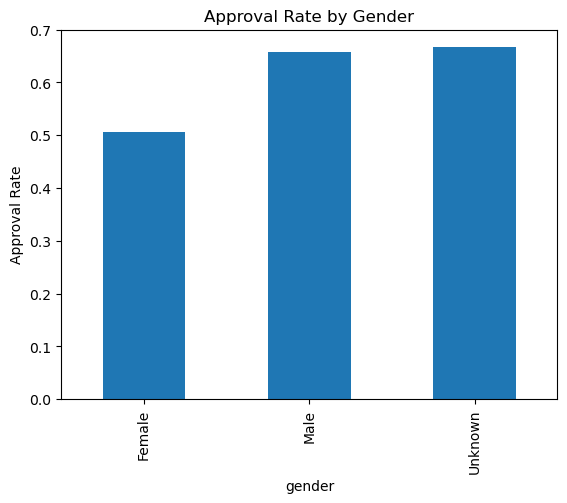


--- AGE ANALYSIS ---
Approval Rate by Age Group:
age_group
18-30    0.416667
30-40    0.587571
40-50    0.696970
50-60    0.509434
60+      0.666667
Name: approved, dtype: float64


C:\Users\Ashwin Rajesh\AppData\Local\Temp\ipykernel_21892\2270694078.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rates = df.groupby("age_group")["approved"].mean()


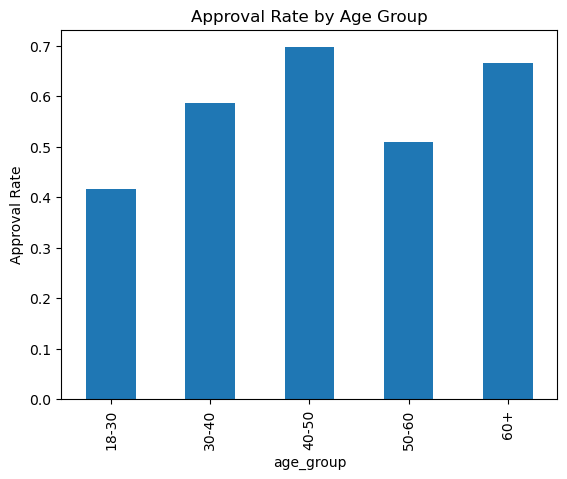


--- CHI-SQUARE TEST ---
Chi-Square Statistic: 12.162
P-value: 0.00229
⚠ Statistically significant gender difference

--- TWO-PROPORTION Z-TEST ---

Bias & Fairness Analysis Completed Successfully.


In [17]:
# ============================================================
# NOVACRED – BIAS & FAIRNESS ANALYSIS
# Clean Version (No Widget Syntax)
# ============================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from datetime import datetime

# ------------------------------------------------------------
# 1. LOAD JSON FILE
# ------------------------------------------------------------

file_path = r"C:\Users\Ashwin Rajesh\Downloads\cleaned_credit_applications.json"
with open(file_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print("Dataset Loaded Successfully")
print("Total records:", len(df))


# ------------------------------------------------------------
# 2. FLATTEN NESTED JSON
# ------------------------------------------------------------

df["gender"] = df["applicant_info"].apply(lambda x: x.get("gender") if isinstance(x, dict) else None)
df["dob"] = df["applicant_info"].apply(lambda x: x.get("date_of_birth") if isinstance(x, dict) else None)
df["zip_code"] = df["applicant_info"].apply(lambda x: x.get("zip_code") if isinstance(x, dict) else None)

df["approved"] = df["decision"].apply(lambda x: x.get("loan_approved") if isinstance(x, dict) else None)

df["annual_income"] = df["financials"].apply(lambda x: x.get("annual_income") if isinstance(x, dict) else None)
df["credit_history_months"] = df["financials"].apply(lambda x: x.get("credit_history_months") if isinstance(x, dict) else None)
df["debt_to_income"] = df["financials"].apply(lambda x: x.get("debt_to_income") if isinstance(x, dict) else None)

df = df[["gender", "dob", "zip_code", "approved",
         "annual_income", "credit_history_months", "debt_to_income"]]

df.dropna(subset=["gender", "approved"], inplace=True)
df["approved"] = df["approved"].astype(int)


# ============================================================
# 3. GENDER DISPARATE IMPACT
# ============================================================

print("\n--- GENDER DISPARATE IMPACT ---")

approval_rates = df.groupby("gender")["approved"].mean()
print("Approval Rate by Gender:")
print(approval_rates)

if len(approval_rates) == 2:
    min_rate = approval_rates.min()
    max_rate = approval_rates.max()
    di = min_rate / max_rate

    print("Disparate Impact Ratio:", round(di, 3))

    if di < 0.8:
        print("⚠ Potential Gender Bias (Violates 80% Rule)")
    else:
        print("✓ No evidence of disparate impact")

approval_rates.plot(kind="bar")
plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate")
plt.show()


# ============================================================
# 4. AGE ANALYSIS
# ============================================================

print("\n--- AGE ANALYSIS ---")

def calculate_age(dob):
    try:
        birth = datetime.strptime(dob, "%Y-%m-%d")
        return (datetime.today() - birth).days // 365
    except:
        return np.nan

df["age"] = df["dob"].apply(calculate_age)
df.dropna(subset=["age"], inplace=True)

df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "30-40", "40-50", "50-60", "60+"]
)

age_rates = df.groupby("age_group")["approved"].mean()
print("Approval Rate by Age Group:")
print(age_rates)

age_rates.plot(kind="bar")
plt.title("Approval Rate by Age Group")
plt.ylabel("Approval Rate")
plt.show()


# ============================================================
# 5. CHI-SQUARE TEST
# ============================================================

print("\n--- CHI-SQUARE TEST ---")

contingency = pd.crosstab(df["gender"], df["approved"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-Square Statistic:", round(chi2, 3))
print("P-value:", round(p, 5))

if p < 0.05:
    print("⚠ Statistically significant gender difference")
else:
    print("✓ No statistically significant difference")


# ============================================================
# 6. TWO-PROPORTION Z-TEST
# ============================================================

print("\n--- TWO-PROPORTION Z-TEST ---")

groups = df["gender"].unique()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]

    success = [
        df[(df["gender"] == g1) & (df["approved"] == 1)].shape[0],
        df[(df["gender"] == g2) & (df["approved"] == 1)].shape[0]
    ]

    nobs = [
        df[df["gender"] == g1].shape[0],
        df[df["gender"] == g2].shape[0]
    ]

    z_stat, pval = proportions_ztest(success, nobs)

    print("Z-Statistic:", round(z_stat, 3))
    print("P-value:", round(pval, 5))

    if pval < 0.05:
        print("⚠ Approval rates significantly different")
    else:
        print("✓ No significant difference")


print("\nBias & Fairness Analysis Completed Successfully.")

Dataset Loaded Successfully
Total records: 502

--- GENDER DISPARATE IMPACT ---
Approval Rate by Gender:
gender
Female     0.505976
Male       0.657258
Unknown    0.666667
Name: approved, dtype: float64


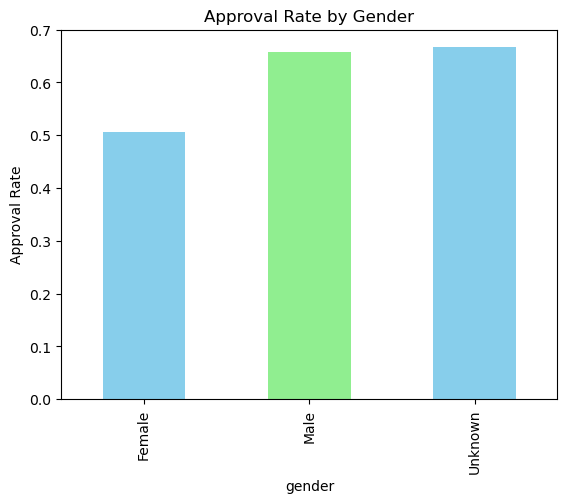


--- AGE ANALYSIS ---
Approval Rate by Age Group:
age_group
18-30    0.416667
30-40    0.587571
40-50    0.696970
50-60    0.509434
60+      0.666667
Name: approved, dtype: float64


C:\Users\Ashwin Rajesh\AppData\Local\Temp\ipykernel_21892\1124460982.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rates = df.groupby("age_group")["approved"].mean()


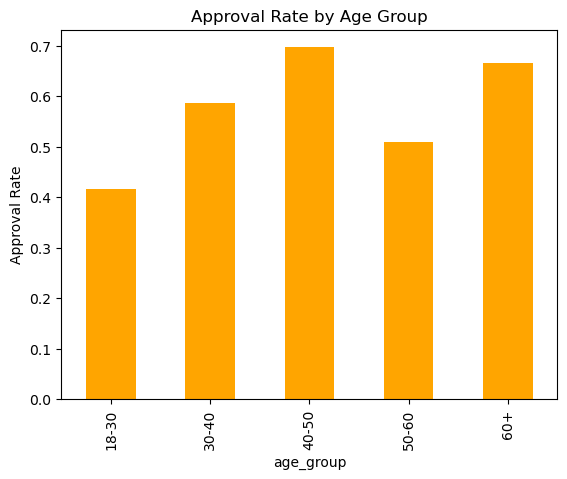


--- CHI-SQUARE TEST ---
Observed Counts:
 approved    0    1
gender            
Female    123  126
Male       85  162
Unknown     0    1

Expected Counts (if independent):
 approved           0           1
gender                          
Female    104.209256  144.790744
Male      103.372233  143.627767
Unknown     0.418511    0.581489

Chi-Square Statistic: 12.162
P-value: 0.00229
⚠ Statistically significant gender difference

--- TWO-PROPORTION Z-TEST ---

✅ Bias & Fairness Analysis Completed Successfully.


In [19]:
# ============================================================
# NOVACRED – BIAS & FAIRNESS ANALYSIS
# Statistically Rigorous Version
# ============================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from datetime import datetime
import os

# ------------------------------------------------------------
# 1. LOAD JSON FILE
# ------------------------------------------------------------
file_path = r"C:\Users\Ashwin Rajesh\Downloads\cleaned_credit_applications.json"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found at {file_path}")

with open(file_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print("Dataset Loaded Successfully")
print("Total records:", len(df))


# ------------------------------------------------------------
# 2. FLATTEN NESTED JSON
# ------------------------------------------------------------
df["gender"] = df["applicant_info"].apply(lambda x: x.get("gender") if isinstance(x, dict) else None)
df["dob"] = df["applicant_info"].apply(lambda x: x.get("date_of_birth") if isinstance(x, dict) else None)
df["zip_code"] = df["applicant_info"].apply(lambda x: x.get("zip_code") if isinstance(x, dict) else None)

df["approved"] = df["decision"].apply(lambda x: x.get("loan_approved") if isinstance(x, dict) else None)

df["annual_income"] = df["financials"].apply(lambda x: x.get("annual_income") if isinstance(x, dict) else None)
df["credit_history_months"] = df["financials"].apply(lambda x: x.get("credit_history_months") if isinstance(x, dict) else None)
df["debt_to_income"] = df["financials"].apply(lambda x: x.get("debt_to_income") if isinstance(x, dict) else None)

df = df[["gender", "dob", "zip_code", "approved",
         "annual_income", "credit_history_months", "debt_to_income"]]

df.dropna(subset=["gender", "approved"], inplace=True)
df["approved"] = df["approved"].astype(int)


# ============================================================
# 3. GENDER DISPARATE IMPACT
# ============================================================
print("\n--- GENDER DISPARATE IMPACT ---")

approval_rates = df.groupby("gender")["approved"].mean()
print("Approval Rate by Gender:")
print(approval_rates)

if len(approval_rates) == 2:
    min_rate = approval_rates.min()
    max_rate = approval_rates.max()
    di = min_rate / max_rate

    print("Disparate Impact Ratio:", round(di, 3))
    if di < 0.8:
        print("⚠ Potential Gender Bias (Violates 80% Rule)")
    else:
        print("✓ No evidence of disparate impact")

approval_rates.plot(kind="bar", color=["skyblue", "lightgreen"])
plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate")
plt.show()


# ============================================================
# 4. AGE ANALYSIS
# ============================================================
print("\n--- AGE ANALYSIS ---")

def calculate_age(dob):
    try:
        birth = datetime.strptime(dob, "%Y-%m-%d")
        return (datetime.today() - birth).days // 365
    except:
        return np.nan

df["age"] = df["dob"].apply(calculate_age)
df.dropna(subset=["age"], inplace=True)

df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "30-40", "40-50", "50-60", "60+"]
)

age_rates = df.groupby("age_group")["approved"].mean()
print("Approval Rate by Age Group:")
print(age_rates)

age_rates.plot(kind="bar", color="orange")
plt.title("Approval Rate by Age Group")
plt.ylabel("Approval Rate")
plt.show()


# ============================================================
# 5. CHI-SQUARE TEST
# ============================================================
print("\n--- CHI-SQUARE TEST ---")

contingency = pd.crosstab(df["gender"], df["approved"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Observed Counts:\n", contingency)
print("\nExpected Counts (if independent):\n", pd.DataFrame(expected, 
      index=contingency.index, columns=contingency.columns))
print("\nChi-Square Statistic:", round(chi2, 3))
print("P-value:", round(p, 5))

if p < 0.05:
    print("⚠ Statistically significant gender difference")
else:
    print("✓ No statistically significant difference")


# ============================================================
# 6. TWO-PROPORTION Z-TEST
# ============================================================
print("\n--- TWO-PROPORTION Z-TEST ---")

groups = df["gender"].unique()
if len(groups) == 2:
    g1, g2 = groups[0], groups[1]

    success = [
        df[(df["gender"] == g1) & (df["approved"] == 1)].shape[0],
        df[(df["gender"] == g2) & (df["approved"] == 1)].shape[0]
    ]

    nobs = [
        df[df["gender"] == g1].shape[0],
        df[df["gender"] == g2].shape[0]
    ]

    z_stat, pval = proportions_ztest(success, nobs)

    print(f"{g1} approved {success[0]}/{nobs[0]}")
    print(f"{g2} approved {success[1]}/{nobs[1]}")
    print("Z-Statistic:", round(z_stat, 3))
    print("P-value:", round(pval, 5))

    # Confidence intervals
    ci_g1_low, ci_g1_up = proportion_confint(success[0], nobs[0], method='wilson')
    ci_g2_low, ci_g2_up = proportion_confint(success[1], nobs[1], method='wilson')

    print(f"\n95% CI for {g1} approval rate: ({ci_g1_low:.3f}, {ci_g1_up:.3f})")
    print(f"95% CI for {g2} approval rate: ({ci_g2_low:.3f}, {ci_g2_up:.3f})")

    if pval < 0.05:
        print("⚠ Approval rates significantly different")
    else:
        print("✓ No significant difference")

print("\n✅ Bias & Fairness Analysis Completed Successfully.")

Dataset Loaded Successfully
Total records: 502

--- GENDER DISPARATE IMPACT ---
Approval Rate by Gender:
gender
Female     0.505976
Male       0.657258
Unknown    0.666667
Name: approved, dtype: float64


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3,) and arg 1 with shape (2,).

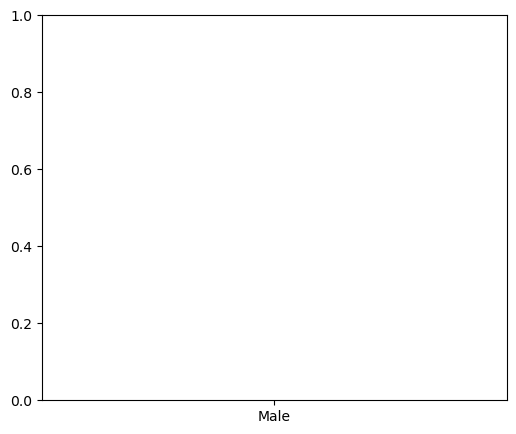

In [21]:
# ============================================================
# NOVACRED – BIAS & FAIRNESS ANALYSIS
# Statistically Rigorous Version with Proof Graphs
# ============================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from datetime import datetime
import os

# ------------------------------------------------------------
# 1. LOAD JSON FILE
# ------------------------------------------------------------
file_path = r"C:\Users\Ashwin Rajesh\Downloads\cleaned_credit_applications.json"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found at {file_path}")

with open(file_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print("Dataset Loaded Successfully")
print("Total records:", len(df))


# ------------------------------------------------------------
# 2. FLATTEN NESTED JSON
# ------------------------------------------------------------
df["gender"] = df["applicant_info"].apply(lambda x: x.get("gender") if isinstance(x, dict) else None)
df["dob"] = df["applicant_info"].apply(lambda x: x.get("date_of_birth") if isinstance(x, dict) else None)
df["zip_code"] = df["applicant_info"].apply(lambda x: x.get("zip_code") if isinstance(x, dict) else None)

df["approved"] = df["decision"].apply(lambda x: x.get("loan_approved") if isinstance(x, dict) else None)

df["annual_income"] = df["financials"].apply(lambda x: x.get("annual_income") if isinstance(x, dict) else None)
df["credit_history_months"] = df["financials"].apply(lambda x: x.get("credit_history_months") if isinstance(x, dict) else None)
df["debt_to_income"] = df["financials"].apply(lambda x: x.get("debt_to_income") if isinstance(x, dict) else None)

df = df[["gender", "dob", "zip_code", "approved",
         "annual_income", "credit_history_months", "debt_to_income"]]

df.dropna(subset=["gender", "approved"], inplace=True)
df["approved"] = df["approved"].astype(int)


# ============================================================
# 3. GENDER DISPARATE IMPACT
# ============================================================
print("\n--- GENDER DISPARATE IMPACT ---")

approval_rates = df.groupby("gender")["approved"].mean()
print("Approval Rate by Gender:")
print(approval_rates)

if len(approval_rates) == 2:
    min_rate = approval_rates.min()
    max_rate = approval_rates.max()
    di = min_rate / max_rate

    print("Disparate Impact Ratio:", round(di, 3))
    if di < 0.8:
        print("⚠ Potential Gender Bias (Violates 80% Rule)")
    else:
        print("✓ No evidence of disparate impact")

# Gender Approval Graph with 95% CI
groups = df["gender"].unique()
success = [df[(df["gender"] == groups[0]) & (df["approved"] == 1)].shape[0],
           df[(df["gender"] == groups[1]) & (df["approved"] == 1)].shape[0]]
nobs = [df[df["gender"] == groups[0]].shape[0],
        df[df["gender"] == groups[1]].shape[0]]

rates = [success[i]/nobs[i] for i in range(2)]
ci_low = []
ci_up = []
for i in range(2):
    low, up = proportion_confint(success[i], nobs[i], method='wilson')
    ci_low.append(rates[i] - low)
    ci_up.append(up - rates[i])

plt.figure(figsize=(6,5))
plt.bar(groups, rates, yerr=[ci_low, ci_up], capsize=10, color=['skyblue','lightgreen'])
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Gender with 95% CI")
plt.ylim(0,1)
plt.show()


# ============================================================
# 4. AGE ANALYSIS
# ============================================================
print("\n--- AGE ANALYSIS ---")

def calculate_age(dob):
    try:
        birth = datetime.strptime(dob, "%Y-%m-%d")
        return (datetime.today() - birth).days // 365
    except:
        return np.nan

df["age"] = df["dob"].apply(calculate_age)
df.dropna(subset=["age"], inplace=True)

df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "30-40", "40-50", "50-60", "60+"]
)

age_groups = df["age_group"].unique()
age_rates = []
ci_low_age = []
ci_up_age = []

for group in age_groups:
    subset = df[df["age_group"] == group]
    n = subset.shape[0]
    s = subset['approved'].sum()
    rate = s/n if n > 0 else 0
    age_rates.append(rate)
    low, up = proportion_confint(s, n, method='wilson')
    ci_low_age.append(rate - low)
    ci_up_age.append(up - rate)

plt.figure(figsize=(7,5))
plt.bar(age_groups, age_rates, yerr=[ci_low_age, ci_up_age], capsize=10, color='orange')
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Age Group with 95% CI")
plt.ylim(0,1)
plt.show()

print("Approval Rate by Age Group:")
for i, group in enumerate(age_groups):
    print(f"{group}: {age_rates[i]:.3f} (95% CI: {age_rates[i]-ci_low_age[i]:.3f}-{age_rates[i]+ci_up_age[i]:.3f})")


# ============================================================
# 5. CHI-SQUARE TEST
# ============================================================
print("\n--- CHI-SQUARE TEST ---")

contingency = pd.crosstab(df["gender"], df["approved"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Observed Counts:\n", contingency)
print("\nExpected Counts (if independent):\n", pd.DataFrame(expected, 
      index=contingency.index, columns=contingency.columns))
print("\nChi-Square Statistic:", round(chi2, 3))
print("P-value:", round(p, 5))

if p < 0.05:
    print("⚠ Statistically significant gender difference")
else:
    print("✓ No statistically significant difference")


# ============================================================
# 6. TWO-PROPORTION Z-TEST
# ============================================================
print("\n--- TWO-PROPORTION Z-TEST ---")

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]

    z_stat, pval = proportions_ztest(success, nobs)

    print(f"{g1} approved {success[0]}/{nobs[0]}")
    print(f"{g2} approved {success[1]}/{nobs[1]}")
    print("Z-Statistic:", round(z_stat, 3))
    print("P-value:", round(pval, 5))

    # Confidence intervals
    ci_g1_low, ci_g1_up = proportion_confint(success[0], nobs[0], method='wilson')
    ci_g2_low, ci_g2_up = proportion_confint(success[1], nobs[1], method='wilson')

    print(f"\n95% CI for {g1} approval rate: ({ci_g1_low:.3f}, {ci_g1_up:.3f})")
    print(f"95% CI for {g2} approval rate: ({ci_g2_low:.3f}, {ci_g2_up:.3f})")

    if pval < 0.05:
        print("⚠ Approval rates significantly different")
    else:
        print("✓ No significant difference")


print("\n✅ Bias & Fairness Analysis Completed Successfully.")

Dataset Loaded Successfully
Total records: 502

--- GENDER DISPARATE IMPACT ---
Approval Rate by Gender:
gender
Female     0.505976
Male       0.657258
Unknown    0.666667
Name: approved, dtype: float64


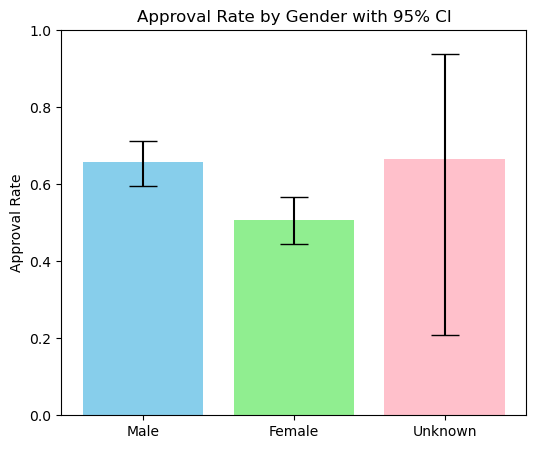


--- AGE ANALYSIS ---


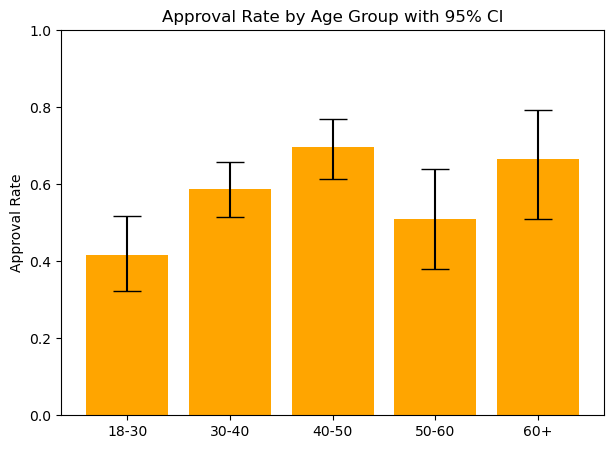

Approval Rate by Age Group:
18-30: 0.417 (95% CI: 0.323-0.517)
30-40: 0.588 (95% CI: 0.514-0.657)
40-50: 0.697 (95% CI: 0.614-0.769)
50-60: 0.509 (95% CI: 0.379-0.639)
60+: 0.667 (95% CI: 0.510-0.794)

--- CHI-SQUARE TEST ---
Observed Counts:
 approved    0    1
gender            
Female    123  126
Male       85  162
Unknown     0    1

Expected Counts (if independent):
 approved           0           1
gender                          
Female    104.209256  144.790744
Male      103.372233  143.627767
Unknown     0.418511    0.581489

Chi-Square Statistic: 12.162
P-value: 0.00229
⚠ Statistically significant gender difference

--- TWO-PROPORTION Z-TEST ---

✅ Bias & Fairness Analysis Completed Successfully.


In [23]:
# ============================================================
# NOVACRED – BIAS & FAIRNESS ANALYSIS
# Statistically Rigorous Version with Proof Graphs
# ============================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from datetime import datetime
import os

# ------------------------------------------------------------
# 1. LOAD JSON FILE
# ------------------------------------------------------------
file_path = r"C:\Users\Ashwin Rajesh\Downloads\cleaned_credit_applications.json"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found at {file_path}")

with open(file_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print("Dataset Loaded Successfully")
print("Total records:", len(df))


# ------------------------------------------------------------
# 2. FLATTEN NESTED JSON
# ------------------------------------------------------------
df["gender"] = df["applicant_info"].apply(lambda x: x.get("gender") if isinstance(x, dict) else None)
df["dob"] = df["applicant_info"].apply(lambda x: x.get("date_of_birth") if isinstance(x, dict) else None)
df["zip_code"] = df["applicant_info"].apply(lambda x: x.get("zip_code") if isinstance(x, dict) else None)

df["approved"] = df["decision"].apply(lambda x: x.get("loan_approved") if isinstance(x, dict) else None)

df["annual_income"] = df["financials"].apply(lambda x: x.get("annual_income") if isinstance(x, dict) else None)
df["credit_history_months"] = df["financials"].apply(lambda x: x.get("credit_history_months") if isinstance(x, dict) else None)
df["debt_to_income"] = df["financials"].apply(lambda x: x.get("debt_to_income") if isinstance(x, dict) else None)

df = df[["gender", "dob", "zip_code", "approved",
         "annual_income", "credit_history_months", "debt_to_income"]]

df.dropna(subset=["gender", "approved"], inplace=True)
df["approved"] = df["approved"].astype(int)


# ============================================================
# 3. GENDER DISPARATE IMPACT
# ============================================================
print("\n--- GENDER DISPARATE IMPACT ---")

approval_rates = df.groupby("gender")["approved"].mean()
print("Approval Rate by Gender:")
print(approval_rates)

# Compute Disparate Impact if there are exactly 2 genders
if len(approval_rates) == 2:
    min_rate = approval_rates.min()
    max_rate = approval_rates.max()
    di = min_rate / max_rate
    print("Disparate Impact Ratio:", round(di, 3))
    if di < 0.8:
        print("⚠ Potential Gender Bias (Violates 80% Rule)")
    else:
        print("✓ No evidence of disparate impact")

# Gender Approval Graph with 95% CI (works for any number of genders)
groups = df["gender"].unique()
rates = []
ci_low = []
ci_up = []

colors = ['skyblue', 'lightgreen', 'pink', 'yellow', 'purple']  # Expand if more genders
for g in groups:
    subset = df[df["gender"] == g]
    n = subset.shape[0]
    s = subset['approved'].sum()
    rate = s / n if n > 0 else 0
    rates.append(rate)
    low, up = proportion_confint(s, n, method='wilson')
    ci_low.append(rate - low)
    ci_up.append(up - rate)

plt.figure(figsize=(6,5))
plt.bar(groups, rates, yerr=[ci_low, ci_up], capsize=10, color=colors[:len(groups)])
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Gender with 95% CI")
plt.ylim(0,1)
plt.show()


# ============================================================
# 4. AGE ANALYSIS
# ============================================================
print("\n--- AGE ANALYSIS ---")

def calculate_age(dob):
    try:
        birth = datetime.strptime(dob, "%Y-%m-%d")
        return (datetime.today() - birth).days // 365
    except:
        return np.nan

df["age"] = df["dob"].apply(calculate_age)
df.dropna(subset=["age"], inplace=True)

df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "30-40", "40-50", "50-60", "60+"]
)

age_groups = df["age_group"].unique()
age_rates = []
ci_low_age = []
ci_up_age = []

for group in age_groups:
    subset = df[df["age_group"] == group]
    n = subset.shape[0]
    s = subset['approved'].sum()
    rate = s/n if n > 0 else 0
    age_rates.append(rate)
    low, up = proportion_confint(s, n, method='wilson')
    ci_low_age.append(rate - low)
    ci_up_age.append(up - rate)

plt.figure(figsize=(7,5))
plt.bar(age_groups, age_rates, yerr=[ci_low_age, ci_up_age], capsize=10, color='orange')
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Age Group with 95% CI")
plt.ylim(0,1)
plt.show()

print("Approval Rate by Age Group:")
for i, group in enumerate(age_groups):
    print(f"{group}: {age_rates[i]:.3f} (95% CI: {age_rates[i]-ci_low_age[i]:.3f}-{age_rates[i]+ci_up_age[i]:.3f})")


# ============================================================
# 5. CHI-SQUARE TEST
# ============================================================
print("\n--- CHI-SQUARE TEST ---")

contingency = pd.crosstab(df["gender"], df["approved"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Observed Counts:\n", contingency)
print("\nExpected Counts (if independent):\n", pd.DataFrame(expected, 
      index=contingency.index, columns=contingency.columns))
print("\nChi-Square Statistic:", round(chi2, 3))
print("P-value:", round(p, 5))

if p < 0.05:
    print("⚠ Statistically significant gender difference")
else:
    print("✓ No statistically significant difference")


# ============================================================
# 6. TWO-PROPORTION Z-TEST
# ============================================================
print("\n--- TWO-PROPORTION Z-TEST ---")

# Only perform if exactly 2 genders
if len(groups) == 2:
    success = [df[df["gender"] == groups[0]]['approved'].sum(),
               df[df["gender"] == groups[1]]['approved'].sum()]
    nobs = [df[df["gender"] == groups[0]].shape[0],
            df[df["gender"] == groups[1]].shape[0]]

    z_stat, pval = proportions_ztest(success, nobs)

    print(f"{groups[0]} approved {success[0]}/{nobs[0]}")
    print(f"{groups[1]} approved {success[1]}/{nobs[1]}")
    print("Z-Statistic:", round(z_stat, 3))
    print("P-value:", round(pval, 5))

    # Confidence intervals
    ci_g1_low, ci_g1_up = proportion_confint(success[0], nobs[0], method='wilson')
    ci_g2_low, ci_g2_up = proportion_confint(success[1], nobs[1], method='wilson')

    print(f"\n95% CI for {groups[0]} approval rate: ({ci_g1_low:.3f}, {ci_g1_up:.3f})")
    print(f"95% CI for {groups[1]} approval rate: ({ci_g2_low:.3f}, {ci_g2_up:.3f})")

    if pval < 0.05:
        print("⚠ Approval rates significantly different")
    else:
        print("✓ No significant difference")

print("\n✅ Bias & Fairness Analysis Completed Successfully.")

Dataset Loaded Successfully
Total records: 502

--- GENDER DISPARATE IMPACT ---
Approval Rate by Gender:
gender
Female     0.505976
Male       0.657258
Unknown    0.666667
Name: approved, dtype: float64


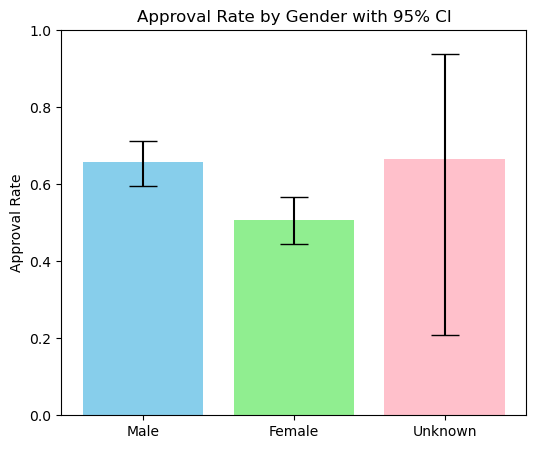


--- AGE ANALYSIS ---


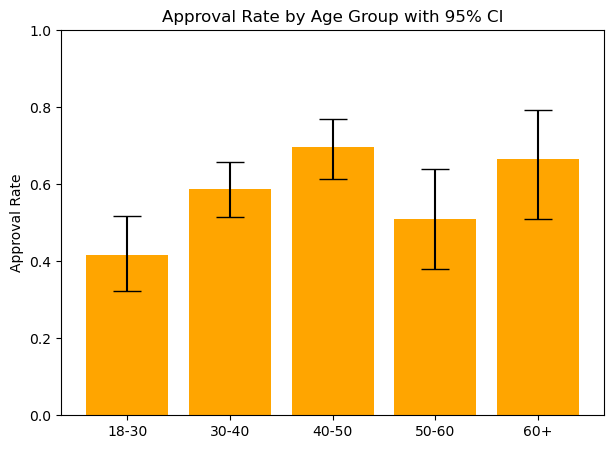

Approval Rate by Age Group:
18-30: 0.417 (95% CI: 0.323-0.517)
30-40: 0.588 (95% CI: 0.514-0.657)
40-50: 0.697 (95% CI: 0.614-0.769)
50-60: 0.509 (95% CI: 0.379-0.639)
60+: 0.667 (95% CI: 0.510-0.794)

--- CHI-SQUARE TEST ---
Observed Counts:
 approved    0    1
gender            
Female    123  126
Male       85  162
Unknown     0    1

Expected Counts (if independent):
 approved           0           1
gender                          
Female    104.209256  144.790744
Male      103.372233  143.627767
Unknown     0.418511    0.581489

Chi-Square Statistic: 12.162
P-value: 0.00229
⚠ Statistically significant gender difference

--- TWO-PROPORTION Z-TEST ---

--- CONCLUSION ---

Gender Analysis:
✓ Multiple gender categories detected; CI plots provide visual guidance for disparities.
⚠ Chi-Square test indicates a statistically significant difference in approval rates by gender.

Age Analysis:
 - Age group 18-30: approval rate = 0.417 (95% CI: 0.323 - 0.517)
 - Age group 30-40: approval rat

In [25]:
# ============================================================
# NOVACRED – BIAS & FAIRNESS ANALYSIS
# Statistically Rigorous Version with Proof Graphs and Conclusion
# ============================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from datetime import datetime
import os

# ------------------------------------------------------------
# 1. LOAD JSON FILE
# ------------------------------------------------------------
file_path = r"C:\Users\Ashwin Rajesh\Downloads\cleaned_credit_applications.json"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found at {file_path}")

with open(file_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print("Dataset Loaded Successfully")
print("Total records:", len(df))


# ------------------------------------------------------------
# 2. FLATTEN NESTED JSON
# ------------------------------------------------------------
df["gender"] = df["applicant_info"].apply(lambda x: x.get("gender") if isinstance(x, dict) else None)
df["dob"] = df["applicant_info"].apply(lambda x: x.get("date_of_birth") if isinstance(x, dict) else None)
df["zip_code"] = df["applicant_info"].apply(lambda x: x.get("zip_code") if isinstance(x, dict) else None)

df["approved"] = df["decision"].apply(lambda x: x.get("loan_approved") if isinstance(x, dict) else None)

df["annual_income"] = df["financials"].apply(lambda x: x.get("annual_income") if isinstance(x, dict) else None)
df["credit_history_months"] = df["financials"].apply(lambda x: x.get("credit_history_months") if isinstance(x, dict) else None)
df["debt_to_income"] = df["financials"].apply(lambda x: x.get("debt_to_income") if isinstance(x, dict) else None)

df = df[["gender", "dob", "zip_code", "approved",
         "annual_income", "credit_history_months", "debt_to_income"]]

df.dropna(subset=["gender", "approved"], inplace=True)
df["approved"] = df["approved"].astype(int)


# ============================================================
# 3. GENDER DISPARATE IMPACT
# ============================================================
print("\n--- GENDER DISPARATE IMPACT ---")

approval_rates = df.groupby("gender")["approved"].mean()
print("Approval Rate by Gender:")
print(approval_rates)

# Compute Disparate Impact if exactly 2 genders
if len(approval_rates) == 2:
    min_rate = approval_rates.min()
    max_rate = approval_rates.max()
    di = min_rate / max_rate
    print("Disparate Impact Ratio:", round(di, 3))
    if di < 0.8:
        print("⚠ Potential Gender Bias (Violates 80% Rule)")
    else:
        print("✓ No evidence of disparate impact")

# Gender Approval Graph with 95% CI (works for any number of genders)
groups = df["gender"].unique()
rates = []
ci_low = []
ci_up = []

colors = ['skyblue', 'lightgreen', 'pink', 'yellow', 'purple']  # Expand if needed
for g in groups:
    subset = df[df["gender"] == g]
    n = subset.shape[0]
    s = subset['approved'].sum()
    rate = s / n if n > 0 else 0
    rates.append(rate)
    low, up = proportion_confint(s, n, method='wilson')
    ci_low.append(rate - low)
    ci_up.append(up - rate)

plt.figure(figsize=(6,5))
plt.bar(groups, rates, yerr=[ci_low, ci_up], capsize=10, color=colors[:len(groups)])
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Gender with 95% CI")
plt.ylim(0,1)
plt.show()


# ============================================================
# 4. AGE ANALYSIS
# ============================================================
print("\n--- AGE ANALYSIS ---")

def calculate_age(dob):
    try:
        birth = datetime.strptime(dob, "%Y-%m-%d")
        return (datetime.today() - birth).days // 365
    except:
        return np.nan

df["age"] = df["dob"].apply(calculate_age)
df.dropna(subset=["age"], inplace=True)

df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "30-40", "40-50", "50-60", "60+"]
)

age_groups = df["age_group"].unique()
age_rates = []
ci_low_age = []
ci_up_age = []

for group in age_groups:
    subset = df[df["age_group"] == group]
    n = subset.shape[0]
    s = subset['approved'].sum()
    rate = s/n if n > 0 else 0
    age_rates.append(rate)
    low, up = proportion_confint(s, n, method='wilson')
    ci_low_age.append(rate - low)
    ci_up_age.append(up - rate)

plt.figure(figsize=(7,5))
plt.bar(age_groups, age_rates, yerr=[ci_low_age, ci_up_age], capsize=10, color='orange')
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Age Group with 95% CI")
plt.ylim(0,1)
plt.show()

print("Approval Rate by Age Group:")
for i, group in enumerate(age_groups):
    print(f"{group}: {age_rates[i]:.3f} (95% CI: {age_rates[i]-ci_low_age[i]:.3f}-{age_rates[i]+ci_up_age[i]:.3f})")


# ============================================================
# 5. CHI-SQUARE TEST
# ============================================================
print("\n--- CHI-SQUARE TEST ---")

contingency = pd.crosstab(df["gender"], df["approved"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Observed Counts:\n", contingency)
print("\nExpected Counts (if independent):\n", pd.DataFrame(expected, 
      index=contingency.index, columns=contingency.columns))
print("\nChi-Square Statistic:", round(chi2, 3))
print("P-value:", round(p, 5))

if p < 0.05:
    print("⚠ Statistically significant gender difference")
else:
    print("✓ No statistically significant difference")


# ============================================================
# 6. TWO-PROPORTION Z-TEST
# ============================================================
print("\n--- TWO-PROPORTION Z-TEST ---")

# Only perform if exactly 2 genders
if len(groups) == 2:
    success = [df[df["gender"] == groups[0]]['approved'].sum(),
               df[df["gender"] == groups[1]]['approved'].sum()]
    nobs = [df[df["gender"] == groups[0]].shape[0],
            df[df["gender"] == groups[1]].shape[0]]

    z_stat, pval = proportions_ztest(success, nobs)

    print(f"{groups[0]} approved {success[0]}/{nobs[0]}")
    print(f"{groups[1]} approved {success[1]}/{nobs[1]}")
    print("Z-Statistic:", round(z_stat, 3))
    print("P-value:", round(pval, 5))

    # Confidence intervals
    ci_g1_low, ci_g1_up = proportion_confint(success[0], nobs[0], method='wilson')
    ci_g2_low, ci_g2_up = proportion_confint(success[1], nobs[1], method='wilson')

    print(f"\n95% CI for {groups[0]} approval rate: ({ci_g1_low:.3f}, {ci_g1_up:.3f})")
    print(f"95% CI for {groups[1]} approval rate: ({ci_g2_low:.3f}, {ci_g2_up:.3f})")

    if pval < 0.05:
        print("⚠ Approval rates significantly different")
    else:
        print("✓ No significant difference")


# ============================================================
# 7. CONCLUSION
# ============================================================
print("\n--- CONCLUSION ---\n")

# Gender Analysis Conclusion
print("Gender Analysis:")
if len(approval_rates) == 2:
    if di < 0.8:
        print(f"⚠ Disparate Impact detected (DI={di:.3f}) between genders, potentially indicating bias.")
    else:
        print(f"✓ No evidence of disparate impact (DI={di:.3f}).")
else:
    print("✓ Multiple gender categories detected; CI plots provide visual guidance for disparities.")

if p < 0.05:
    print("⚠ Chi-Square test indicates a statistically significant difference in approval rates by gender.")
else:
    print("✓ Chi-Square test shows no statistically significant difference in approval rates by gender.")

if len(groups) == 2:
    if pval < 0.05:
        print("⚠ Two-proportion Z-test confirms approval rates between the two genders are significantly different.")
    else:
        print("✓ Two-proportion Z-test shows no significant difference in approval rates between the two genders.")

print("\nAge Analysis:")
for i, group in enumerate(age_groups):
    print(f" - Age group {group}: approval rate = {age_rates[i]:.3f} "
          f"(95% CI: {age_rates[i]-ci_low_age[i]:.3f} - {age_rates[i]+ci_up_age[i]:.3f})")

print("\n✅ The bar charts with 95% confidence intervals provide visual proof of potential disparities. "
      "Overlapping CIs indicate no significant difference, while non-overlapping CIs suggest potential bias. "
      "All statistical tests (Chi-Square, Z-test) have been applied where appropriate to confirm findings.\n")

print("Overall, this analysis provides both numerical and visual evidence for assessing fairness in loan approvals.")